# [AI] 스프린트 미션3 소개
이번 미션에서는 지금까지 배운 지도 학습 알고리즘을 총동원해서, 전 세계에서 가장 유명한 머신러닝 입문 대회인 캐글 타이타닉 대회에 직접 참가합니다.

1912년, 타이타닉호는 첫 항해 중 빙산과 충돌해 침몰했고 승객 2,224명 중 1,502명이 사망했습니다. 생존에는 운도 작용했지만, 데이터를 보면 어떤 집단이 더 많이 살아남았는지 뚜렷한 패턴이 있습니다. 여러분은 승객 정보를 바탕으로 누가 생존했는지(Survived) 예측하는 이진 분류 모델을 만들어, 실제 캐글 리더보드에 제출해 보세요.

이 미션은 데이터를 분석하고 인사이트를 뽑아내는 것보다, 전처리부터 모델 튜닝까지 지도 학습 파이프라인을 얼마나 잘 구축하는지를 확인하는 데 목적이 있습니다. 로지스틱 회귀, 결정트리, 앙상블 기법을 모두 실험해 보고, 어떤 모델과 설정이 가장 좋은 성능을 내는지 직접 확인해 보세요.

In [ ]:
# import kagglehub

# #Download lastest version
# path = kagglehub.competition_download('titanic')

# print("Path to competition file:", path)


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 34.1k/34.1k [00:00<00:00, 14.3MB/s]

Extracting files...
Path to competition file: C:\Users\dsbang\.cache\kagglehub\competitions\titanic


In [25]:
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic' 

import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv(PATH +'/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')

display(train_df)
display(test_df)
#target_df = train_df['Survived']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# 데이터 소개
타이타닉 승객 891명의 정보가 담긴 train 데이터와, 생존 여부를 예측해야 하는 승객 418명의 test 데이터가 제공됩니다.

## 데이터 정의서
|컬럼명 |데이터 타입 | 설명 |
|:-------|:---------:|:---------------|
|PassengerId | int | 승객 고유번호, 제출 파일의 키로 사용됩니다.|
|Survived | int | 타깃 변수. 생존 여부(0:사망, 1:생존). train 데이터에만 존재하고, 예측 대상입니다.|
|Pclass | int | 티켓 등급(1: 1등석, 2: 2등석, 3:3등석). 사회경제적 지위를 대신 보여주는 변수입니다. |
|Name |	object(str) |	승객 이름. Mr, Mrs, Miss, Master 같은 호칭이 포함되어 있습니다.|
|Sex | object	| 성별. |
|Age	|float	|나이. 1살 미만은 소수점으로 표기됩니다.
|SibSp	|int	|함께 탑승한 형제자매와 배우자 수. # of siblings / spouses aboard the Titanic
|Parch	|int	|함께 탑승한 부모와 자녀 수. # of parents / children aboard the Titanic
|Ticket	|object	|티켓 번호.
|Fare	|float	|운임.
|Cabin	|object	|객실 번호.
|Embarked	|object	|탑승 항구(C: Cherbourg, Q: Queenstown, S: Southampton).

In [26]:
display(train_df.head() )
display(test_df.head()) 
TARGET='Survived'
FEATURES=['Pclass','Sex','Age','SibSp','Parch','Fare','Cabin','Embarked']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 1. 데이터 분석
- 중복행, 컬럼별 결측치 비율을 확인 

In [27]:

df = train_df.copy()

print("=" * 60)
print("1. 데이터 기본 구조 및 결측치 요약")
print("=" * 60)
print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print(f"- 중복 행 수: {df.duplicated().sum()}개")
print(f"- 결측 총갯수:  {df.isnull().sum().sum()}개  ")
print(f"- 결측 값있는 행수:  { df.isnull().any(axis=1).sum() }행  ")
print(f"- 결측 행의 전체 비율:  {( df.isnull().any(axis=1).sum() / len(df)).round(4):.1%}  ")

print(f"- 입력 Feasture의 결측 갯수: {df[FEATURES].isnull().sum().sum()}개")
print(f"- 입력 Feasture의 결측 행수: {df[FEATURES].isnull().any(axis=1).sum()}행")    
print(f"- 입력 Feasture의 결측 행의 전체중 비율: {df[FEATURES].isnull().any(axis=1).sum() / len(df):.1%}")  
# 1. 결측값이 있는 컬럼 확인
print("== 컬럼별 결측 수량 확인: ")
display(pd.DataFrame(df.isnull().sum(), columns=['결측수량']))

# 2. 결측값이 있는 각 컬럼별 정보 출력
null_cols = df.isnull().sum()
missing_val_cols = null_cols[null_cols > 0].index

print("=== 결측값이 있는 컬럼별 상세 정보 ===\n")
for col in missing_val_cols:
    print(f" 컬럼명: {col}")
    print(f" 총행수: {len(df[col])}")
    print(f" 결측값 개수: {null_cols[col]}개")
    print(f" 결측값 비율: {null_cols[col]/len(df[col]):.2%}")
    print(f" 최빈값 : { df[col].mode()[0] }")

    if df[col].dtype != 'str':
        print(f" Min값: {df[col].min(numeric_only=True):.2f}")
        print(f" Max값: {df[col].max(numeric_only=True):.2f}")
        print(f" Mean값: {df[col].mean(numeric_only=True):.2f}")
        print(f" Median값: {df[col].median(numeric_only=True):.2f}")    
        print(f" Std값: {df[col].std():.2f}")   


    # dropna=True 옵션으로 결측치를 제외한 유니크 값을 가져옵니다.
    unique_values = df[col].dropna().unique()
    unique_count = df[col].dropna().nunique()

    print(f" 고유값 개수 (결측치 제외): {unique_count}개")
    print(f" 고유값 종류: {unique_values}")
    print(f" 값별 수량: {df[col].value_counts()}")
    print("-" * 40)
    print()

1. 데이터 기본 구조 및 결측치 요약
- 데이터 크기: 891행, 12열
- 중복 행 수: 0개
- 결측 총갯수:  866개  
- 결측 값있는 행수:  708행  
- 결측 행의 전체 비율:  79.5%  
- 입력 Feasture의 결측 갯수: 866개
- 입력 Feasture의 결측 행수: 708행
- 입력 Feasture의 결측 행의 전체중 비율: 79.5%
== 컬럼별 결측 수량 확인: 


,결측수량
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


=== 결측값이 있는 컬럼별 상세 정보 ===

 컬럼명: Age
 총행수: 891
 결측값 개수: 177개
 결측값 비율: 19.87%
 최빈값 : 24.0
 Min값: 0.42
 Max값: 80.00
 Mean값: 29.70
 Median값: 28.00
 Std값: 14.53
 고유값 개수 (결측치 제외): 88개
 고유값 종류: [22.   38.   26.   35.   54.    2.   27.   14.    4.   58.   20.   39.
 55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.   18.
  3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.   16.
 25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.   14.5
 70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.   56.
 50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.   60.
 10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.    0.67
 30.5   0.42 34.5  74.  ]
 값별 수량: Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
----------------------------------------

 컬럼명: Cabin
 총행수: 891
 결측값 개수: 687개
 결측값 비율: 77.10%
 최빈값 : B96

## -. 컬럼별 처리방법 결정
### 중요하지 않은 변수 제외 
####  사유: 유니크한 개별 값
- PassergerID, Name, Ticket, Cabin

### 결측 컬럼별 내용
- Age : 약 20%의 결측, 연령 기준을 볼수 있는 유일한 속성,  최빈값이 24, 평균값 29.7, 중앙값 28
- Cabin : 약 77%의 결측, 객실번호는 유니크한 개별값이나 객실번호의 첫 글자는 배의 구조를 판단할 수 있는 정보 
- Embarked: 약 0.22%의 결측, 결측 비율이 크지않음 'S', 'C', 'Q' 개의 값이 존재하고 S가 72%로 초빈값



## 2. Features 분석

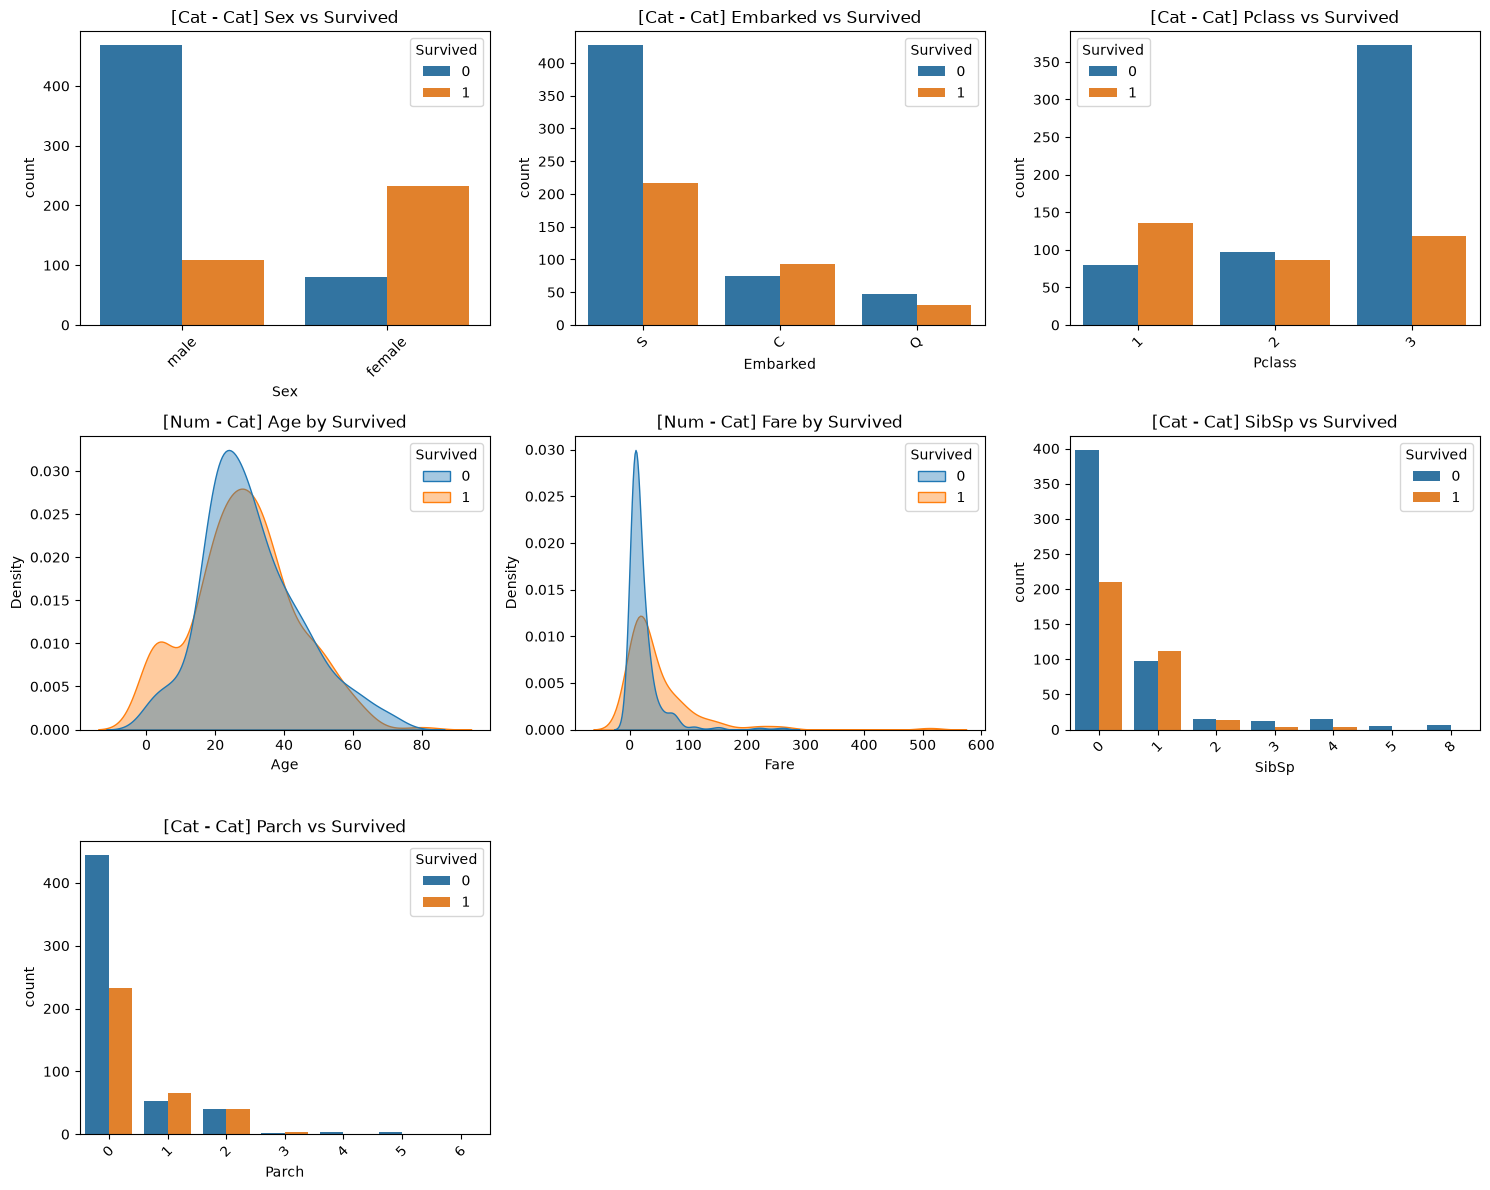

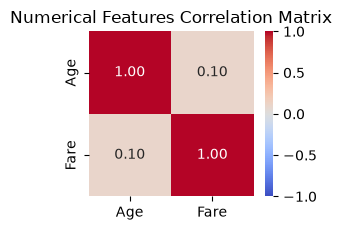

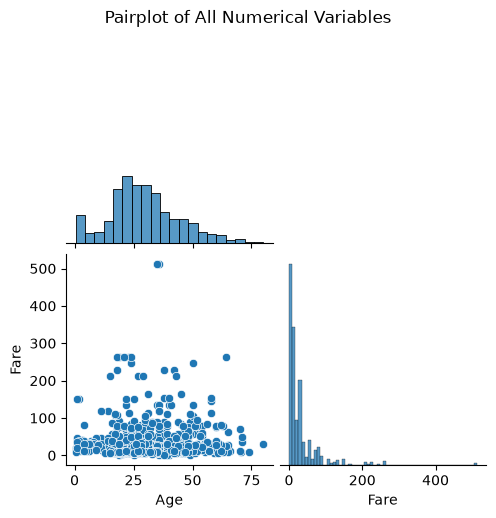

* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심


,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Sex,0.152272,0.543351,1.107806
1,Fare,0.122471,0.257307,1.647642
2,Pclass,0.051664,0.338481,1.680367
3,SibSp,0.037425,0.035322,1.283938
4,Parch,0.032699,0.081629,1.320805
5,Age,0.022344,0.064910,1.213176
6,Embarked,0.015230,0.163517,1.076900


In [29]:
#########################################################################
## Features 데이터 분석 
#########################################################################
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = train_df
# ==========================================
# 타깃 및 변수 상관 그래프 함수
# ==========================================
def plot_feature_relationships(data_df, target_column, feature_columns, max_cols=3, cat_threshold=10, show_pairplot=True):
    """
    미전처리 데이터프레임의 변수 및 타깃 간 관계를 자동 판단하여 시각화하는 함수
    
    Parameters:
    - data_df (pd.DataFrame): 분석할 데이터프레임
    - target_column (str): 타깃 컬럼명
    - feature_columns (list): 분석할 피처 컬럼명 리스트
    - max_cols (int): 한 행에 배치할 최대 서브플롯 개수 (기본값: 3)
    - cat_threshold (int): 정수형 데이터를 범주형으로 판단할 유니크 값 기준 개수
    - show_pairplot (bool): 수치형 변수 간 산점도 행렬(Pairplot) 출력 여부 (기본값: True)
    """
    df = data_df.copy()
    
    # 1. 범주형 데이터 여부 자동 판단 함수
    def is_categorical(series):
        if series.dtype == 'str' or series.dtype == 'object' or series.dtype.name in ['category', 'bool']:
            return True
        if series.nunique() <= cat_threshold and not np.issubdtype(series.dtype, np.floating):
            return True
        return False

    is_target_cat = is_categorical(df[target_column])
    num_features = len(feature_columns)
    
    # 2. 동적 서브플롯 그리드 계산
    n_cols = min(max_cols, num_features)
    n_rows = (num_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if num_features == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # 3. 각 피처와 타깃 간의 관계 시각화
    for i, col in enumerate(feature_columns):
        ax = axes[i]
        is_feature_cat = is_categorical(df[col])
        
        if not is_target_cat and not is_feature_cat:
            sns.regplot(data=df, x=col, y=target_column, ax=ax, 
                        scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
            ax.set_title(f'[Num - Num] {col} vs {target_column}')
            
        elif not is_target_cat and is_feature_cat:
            sns.boxplot(data=df, x=col, y=target_column, ax=ax)
            ax.set_title(f'[Cat - Num] {col} vs {target_column}')
            ax.tick_params(axis='x', rotation=45)
            
        elif is_target_cat and not is_feature_cat:
            sns.kdeplot(data=df, x=col, hue=target_column, ax=ax, fill=True, alpha=0.4, common_norm=False)
            ax.set_title(f'[Num - Cat] {col} by {target_column}')
            
        else:
            sns.countplot(data=df, x=col, hue=target_column, ax=ax)
            ax.set_title(f'[Cat - Cat] {col} vs {target_column}')
            ax.tick_params(axis='x', rotation=45)

    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

    # 4. 수치형 피처 간 상관관계 매트릭스 (Heatmap)
    num_cols = [c for c in feature_columns if not is_categorical(df[c])]
    if len(num_cols) > 1:
        plt.figure(figsize=(min(12, len(num_cols) * 1.5), min(10, len(num_cols) * 1.2)))
        corr = df[num_cols].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
        plt.title('Numerical Features Correlation Matrix')
        plt.tight_layout()
        plt.show()

    # 5. 수치형 변수(피처 + 타깃) 간의 산점도 행렬(Pairplot)
    if show_pairplot:
        all_num_cols = [c for c in feature_columns + [target_column] if not is_categorical(df[c])]
        if len(all_num_cols) > 1:
            # corner=True 옵션으로 중복 대칭 부분(상단) 제거하여 깔끔하게 표시
            sns.pairplot(df[all_num_cols], corner=True)
            plt.suptitle('Pairplot of All Numerical Variables', y=1.02)
            plt.show()

# ==========================================
# 변수 상관 분석 함수 
# ==========================================
def analyze_features(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
        
    # 범주형(문자열) 피처들을 숫자로 안전하게 인코딩 (MI 계산용)
    for col in feature_cols:
        if df_analyzed[col].dtype in ['object', 'string', 'category']:
            le_feat = LabelEncoder()
            df_analyzed[col] = le_feat.fit_transform(df_analyzed[col].astype(str))

    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    # 위에서 인코딩을 거쳤으므로 이제 모든 피처가 수치형으로 분류됩니다.
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")
        
    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median())  # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])
    
    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
        
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)
            
    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)
    
    # print("\n" + "="*60)
    # print(" [변수 분석 리포트] ")
    # print("="*60)
    # print(report_df.round(4))
    # print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심")

    return report_df


# ==========================================
# 데이터 지정 및 함수 실행 
# ==========================================

TARGET = 'Survived'
category_cols = ['Sex', 'Embarked'   ]
numeric_cols = ['Pclass','Age', 'Fare' , 'SibSp', 'Parch']
FEATURES = category_cols + numeric_cols
plot_feature_relationships(data_df=df, target_column=TARGET, feature_columns= FEATURES)
analyze_features(df=df, feature_cols=FEATURES, target_col=TARGET)



## 3. 피쳐 엔지니어링
- Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 title 컬럼 및 희규 카테고리 하나로 정리
```
import re
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 
               'Don', 'Jonkheer', 'Sir', 'Lady', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
print(df['title'].value_counts())
```
- SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용 (본인 기본 +1)
```
df['FamilySize'] =  df['SibSp'] + df['Parch'] +1 
```
- Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 X로 처리(기존에 없는 값)
```
df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]
print(df['DeckofShip'].value_counts())

```
- Age 결측값: 타이틀정보 반영 후 남은 정보는 평균으로 통일
```
df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))
```
- Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
```
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].value_counts())
```
- 사용하지 않을 컬럼
'Name','SibSp','Parch','Ticket','Cabin'

In [ ]:
# ## 2 피쳐 엔지니어링 실행
# - Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 title 컬럼에 저장
### 타이틀 추출 & 컬럼생성
import re
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
# - Age 결측값: Title 기준 평균값으로 채우기
df['Age'] = df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 
               'Don', 'Jonkheer', 'Sir', 'Lady', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
print(df['Title'].value_counts())

# - SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용 (본인 기본 +1)
df['FamilySize'] =  df['SibSp'] + df['Parch'] +1 
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# - Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 unknown 처리(기존에 없는 값)
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')
print(df['Deck'].value_counts())

# Cabin 결측 여부 자체가 생존율과 관련 (기록 있음 = 상위 등급 객실일 가능성)
df['HasCabin'] = df['Cabin'].notna().astype(int)
print(df['HasCabin'].value_counts())
### 성별과 객실 등급
df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)
print(df['Sex_Pclass'].value_counts())
# ```
# - Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
# ```
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].value_counts())
df 

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       22
Name: count, dtype: int64
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64
HasCabin
0    687
1    204
Name: count, dtype: int64
Sex_Pclass
male_3      347
female_3    144
male_1      122
male_2      108
female_1     94
female_2     76
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,Deck,HasCabin,Sex_Pclass
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0,Unknown,0,male_3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,C,1,female_1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1,Unknown,0,female_3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,C,1,female_1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1,Unknown,0,male_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rare,1,1,Unknown,0,male_2
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,1,B,1,female_1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,4,0,Unknown,0,female_3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,1,C,1,male_1


In [32]:
##사용할 Feature만 남기고 정리
df = df.drop(['Name','SibSp','Parch','Ticket','Cabin'], axis=1)
df

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone,Deck,HasCabin,Sex_Pclass
0,1,0,3,male,22.0,7.2500,S,Mr,2,0,Unknown,0,male_3
1,2,1,1,female,38.0,71.2833,C,Mrs,2,0,C,1,female_1
2,3,1,3,female,26.0,7.9250,S,Miss,1,1,Unknown,0,female_3
3,4,1,1,female,35.0,53.1000,S,Mrs,2,0,C,1,female_1
4,5,0,3,male,35.0,8.0500,S,Mr,1,1,Unknown,0,male_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,13.0000,S,Rare,1,1,Unknown,0,male_2
887,888,1,1,female,19.0,30.0000,S,Miss,1,1,B,1,female_1
888,889,0,3,female,21.0,23.4500,S,Miss,4,0,Unknown,0,female_3
889,890,1,1,male,26.0,30.0000,C,Mr,1,1,C,1,male_1


In [33]:
## 범주형 숫자형 Features 정리
TARGET = 'Survived'
category_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck', 'IsAlone', 'HasCabin', 'Sex_Pclass']
numeric_cols = ['Age', 'Fare', 'FamilySize' ]


In [34]:
analyze_features(df=df, feature_cols=category_cols+numeric_cols, target_col=TARGET)


* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Sex_Pclass,0.205725,0.606044,inf
1,Title,0.165706,0.069046,1.477691
2,Sex,0.147318,0.543351,inf
3,Fare,0.136051,0.257307,1.722116
4,FamilySize,0.057858,0.016639,2.264590
5,Pclass,0.046845,0.338481,inf
6,Deck,0.044581,0.301116,13.849017
7,Age,0.039637,0.079141,1.663445
8,HasCabin,0.033741,0.316912,12.707254
9,Embarked,0.026125,0.167675,1.107833


In [47]:
numeric_cols = ['Age', 'Fare', 'FamilySize' ]
category_cols = ['Sex_Pclass', 'Title',  'Sex', 'Pclass', 'HasCabin', 'IsAlone' ] #, 'Deck', 'Embarked'
analyze_features(df=df, feature_cols=category_cols + numeric_cols, target_col=TARGET)

* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Sex_Pclass,0.218133,0.606044,inf
1,Title,0.170271,0.069046,1.473217
2,Fare,0.140903,0.257307,1.624033
3,Sex,0.140562,0.543351,inf
4,FamilySize,0.050383,0.016639,2.197672
5,Pclass,0.046393,0.338481,inf
6,HasCabin,0.046257,0.316912,2.181942
7,Age,0.029306,0.079141,1.662856
8,IsAlone,0.001097,0.203367,2.244330


## 4. 기본 모델 성능평가 (테스트 분리 및 파이프라인을 통한 전처리 스케일링 )
- 테스트 분리
- 파이프라인 구성을 통한 전처리 스케일일

### 순서가 의미 없는 범주형 컬럼을 원-핫 인코딩 처리

### 수치형 StandardScaler 처리




In [48]:
import pandas as pd
import numpy as np 
import random
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
# ----------------------------------------------------
##상수 및 변수
SEED = 42 # random.randint(1,99)
TARGET = 'Survived'
# category_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'Sex_Pclass']
# numeric_cols = ['Pclass','Age', 'Fare', 'FamilySize' , 'IsAlone', 'HasCabin']
FEATURES = category_cols + numeric_cols

# ----------------------------------------------------
## 데이터 생성 할당 
# ----------------------------------------------------
data = df.copy()


# ----------------------------------------------------
## 1. 특성(X)과 타겟(y) 분리 및 Train / Test 분리
# ----------------------------------------------------
#X = data_df.drop(columns=[TARGET])
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED,
    stratify=y #타겟 범주 비율을 균등 유지
    )

# ----------------------------------------------------
# 2. 전처리 파이프라인 구축 (수치형 & 범주형)
# ----------------------------------------------------
#컬럼 구분
cat_features = category_cols
num_features = numeric_cols

# 수치형: 결측치 중앙값 대체 -> 표준화 스케일링
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# 범주형: 결측치 최빈값 대체 -> 원-핫 인코딩
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# ColumnTransformer로 통합
preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='passthrough' #정의되지 않은 컬럼은 그대로 유지
)

# ----------------------------------------------------
# 3. 모델 정의 (기본 성능테스트)
# ----------------------------------------------------
models = {
    'LogisticRegres': LogisticRegression(random_state=SEED),
    'KNeighbors' : KNeighborsClassifier(), #n_neighbors=5
    'DecisionTree': DecisionTreeClassifier(random_state=SEED),
    'RandomForest ': RandomForestClassifier( random_state=SEED ), #n_estimators=100,
    'GradientBoosting ': GradientBoostingClassifier( random_state=SEED), #n_estimators=100,
    #'LGBMClassifier' : LGBMClassifier( learning_rate=0.05, max_depth=5, random_state=SEED, verbose=-1), #n_estimators=100,
    'LGBMClassifier' : LGBMClassifier(random_state=SEED, verbose=-1)  # verbose=-1경고/정보 로그 숨김
}

# ----------------------------------------------------
# 4. 파이프라인 연결 및 평가 수행
# ----------------------------------------------------
results = {}

for name, model in models.items():
    #전처리기와 모델을 하나의 Pipeline으로 결함:
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train 데이터로만 전처리 fit 모델 학습
    model_pipeline.fit(X_train, y_train)

    # Test 데이터 예측
    test_pred = model_pipeline.predict(X_test)
    test_proba = model_pipeline.predict_proba(X_test)[:,1]

    # 성능 측정
    acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred )
    preci = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    roc = roc_auc_score(y_test, test_proba)

    # 모델  CV 5 점수 확인
    #from sklearn.model_selection import cross_val_score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_score = cross_val_score(
        model_pipeline, X_train, y_train, cv=cv, scoring='accuracy' #'roc_auc'
    )
    cv_mean = cv_score.mean()
    cv_std = cv_score.std()
    #print("CV ROC-AUC:", cv_score)

    results[name] = { 'F1-Score': f1, 'Precision': preci, 'Recall': recall ,
                    'ROC-AUC': roc, 'CV_mean': cv_mean, 'CV_std': cv_std}    
#결과 확인
results_df = pd.DataFrame(results).T.sort_values('CV_mean', ascending=False)
print("==== 모델별 기본 성능 비교 ==== random_state:", SEED) 
print('사용된 속성들: ', FEATURES)
print(results_df)



==== 모델별 기본 성능 비교 ==== random_state: 42
사용된 속성들:  ['Sex_Pclass', 'Title', 'Sex', 'Pclass', 'HasCabin', 'IsAlone', 'Age', 'Fare', 'FamilySize']
                   F1-Score  Precision    Recall   ROC-AUC   CV_mean    CV_std
LGBMClassifier     0.771429   0.760563  0.782609  0.843742  0.830090  0.018706
LogisticRegres     0.793893   0.838710  0.753623  0.884321  0.827263  0.022839
GradientBoosting   0.748092   0.790323  0.710145  0.833333  0.821629  0.021125
RandomForest       0.744526   0.750000  0.739130  0.836627  0.814616  0.018457
KNeighbors         0.716418   0.738462  0.695652  0.858498  0.809012  0.018220
DecisionTree       0.733813   0.728571  0.739130  0.780303  0.785108  0.015195


==== 모델별 기본 성능 비교 ==== random_state: 42

사용된 피쳐들: ['Sex_Pclass', 'Title', 'Sex', 'Pclass', 'HasCabin', 'IsAlone', 'Age', 'Fare', 'FamilySize']
기본 옵션으로 6가지 모델 테스트해 봤을 때 CV(scoring='accuracy')평균 점수가 LGBMClassifier가장 높음
|                   |F1-Score  |Precision    |Recall   |ROC-AUC   |CV_mean    |CV_std |
|-------------------|-----------|----------|----------|----------|----------|----------|
|LGBMClassifier     |0.771429   |0.760563  |0.782609  |0.843742  |0.830090  |0.018706
|LogisticRegres     |0.793893   |0.838710  |0.753623  |0.884321  |0.827263  |0.022839
|GradientBoosting   |0.748092   |0.790323  |0.710145  |0.833333  |0.821629  |0.021125
|RandomForest       |0.744526   |0.750000  |0.739130  |0.836627  |0.814616  |0.018457
|KNeighbors         |0.716418   |0.738462  |0.695652  |0.858498  |0.809012  |0.018220
|DecisionTree       |0.733813   |0.728571  |0.739130  |0.780303  |0.785108  |0.015195

# 5. 하이퍼파라미터 최적화 찾기
## 5.1. LogisticRegression GridSearchCV

In [49]:
##################################################################
## LogisticRegression GridSearchCV를 통한 최적의 하이퍼파라미터 최적화
#################################################################
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, roc_curve, auc, average_precision_score


## LogisticRegression
model = LogisticRegression(max_iter =1000, random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model )
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"check: model.classes_: {model.classes_}\n")

print(f"=== [{model} Baseline Performance] ===")
print(classification_report(y_test, y_pred))
print(f"기본 Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"기본 Test ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
# precision, recall, _ = precision_recall_curve(y_test, y_proba)
# print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"기본 PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요
# default 모델 동일 CV로 점수 확인
#from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_score = cross_val_score(
    model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
)
cv_mean = cv_score.mean()
cv_std = cv_score.std()
print("기본 CV ROC-AUC:", cv_mean, "CV Std:", cv_std) 

param_grid = [
    {
        'classifier__l1_ratio': [0.0],  # L2 정규화 사용
        'classifier__C': [ 0.01, 0.1, 1.0, 10.0], #정규화 강도의 역수
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced'] , # 클래스 불균형 가중치 조정
        'classifier__max_iter': [50, 100, 200] , # 최대 반복 횟수
    },
    {
        'classifier__l1_ratio': [1.0], #L1 정규화
        'classifier__C': [ 0.01, 0.1, 1.0, 10.0],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [50, 100, 200] , # 최대 반복 횟수        
    }
]
cv_strategy= StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"=== {model}[GridSearchCV Results] ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC): {grid_search.best_score_:.4f}\n")

# 학습 데이터 ROC-AUC
train_proba = best_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_proba)

# 테스트 데이터 최종 평가
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print(f"=== {model}[Optimized Performance] ===random_state:{SEED}")
print(classification_report(y_test, y_pred_opt))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Search CV ROC-AUC: {grid_search.best_score_:.4f}") # or cross_val_score mean
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요
print(model , '\n', best_model )

check: model.classes_: [0 1]

=== [LogisticRegression(max_iter=1000, random_state=42) Baseline Performance] ===
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.75      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179

기본 Test Accuracy: 0.8492
기본 Test ROC-AUC Score: 0.8843

기본 PR-AUC Average: 0.8502
기본 CV ROC-AUC: 0.8771332710596035 CV Std: 0.02044837824323487
Fitting 5 folds for each of 120 candidates, totalling 600 fits
=== LogisticRegression(max_iter=1000, random_state=42)[GridSearchCV Results] ===
Best Parameters: {'classifier__C': 1.0, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 1.0, 'classifier__max_iter': 50, 'classifier__solver': 'saga'}
Best CV Score (ROC-AUC): 0.8777

=== LogisticRegression(max_iter=1000, random_state=42)[Optimized Performa

c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 5.2. KNeighborsClassifier GridSearchCV 하이퍼파라미터 튜닝

In [50]:
####################################################################################
### KNeighborsClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve,auc,average_precision_score

model = KNeighborsClassifier()
model_pipeline = Pipeline( 
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model )
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"chekc: model.classes_: {model.classes_}\n")

print(f"===[{model} Basic performance]===")
print(classification_report(y_test, y_pred ))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요
print(f"PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요

param_grid = {
    "classifier__n_neighbors": list(range(1, 21, 2)),   # 1,3,5,...,19
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan", "minkowski"],
    "classifier__p": [1, 2]  # minkowski일 때만 의미 있음
}
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy" , #accuracy:클래스 균형 잡힌 일반적인 분류 / f1:클래스 불균형, 두 클래스 다 중요, roc_auc 
    n_jobs=-1, # 모든 CPU코어 사용
    verbose=1  #1.폴드 진행 상황을 간단히 출력 / 2.각 파라미터 조합의 점수까지 좀 더 자세히 출력
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print("best_model.classes_:", best_model.classes_, "\n")

print(f"===={model} GridSearchCV Results ====")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC) {grid_search.best_score_:.4f}")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_pred_opt)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요
print(model,'\n',best_model)


chekc: model.classes_: [0 1]

===[KNeighborsClassifier() Basic performance]===
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

Accuracy: 0.7877
ROC-AUC Score: 0.8585
PR-AUC Score: 0.8412
PR-AUC:    0.7986
PR-AUC Average: 0.7986
Fitting 5 folds for each of 120 candidates, totalling 600 fits
best_model.classes_: [0 1] 

====KNeighborsClassifier() GridSearchCV Results ====
Best parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV Score (ROC-AUC) 0.8371
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy    

## 5.3. DecisionTreeClassifier GridSearchCV 하이퍼파라미터 튜닝

In [51]:
####################################################################################
### DecisionTreeClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
model = DecisionTreeClassifier(random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"check: model.classes_: {model.classes_}\n")

print(f"====[{model} Basic performance]====")
print(classification_report(y_test, y_pred))
print(f"Accuracy : {accuracy_score(y_test, y_pred)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test,y_proba):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요

param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']    
}
grid_search = GridSearchCV(
    model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print("best_model.classes_:", best_model.classes_, "\n")

print(f"===={model} GridSearchCV Results ====")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC) {grid_search.best_score_:.4f}")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_pred_opt)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요
print(model,"\n",best_model)


check: model.classes_: [0 1]

====[DecisionTreeClassifier(random_state=42) Basic performance]====
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       110
           1       0.73      0.74      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Accuracy : 0.7932960893854749
ROC-AUC Score: 0.7803
PR-AUC Score: 0.7778
PR-AUC Average: 0.6489
best_model.classes_: [0 1] 

====DecisionTreeClassifier(random_state=42) GridSearchCV Results ====
Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Best CV Score (ROC-AUC) 0.8231
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       110
           1       0.80      0.58      0.67        69

    accuracy                       

## 5.4. RandomForestClassifier 하이퍼파라미터 튜닝

In [52]:
####################################################################################
### RandomForestClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve,auc
from scipy.stats import randint, uniform

model = RandomForestClassifier(random_state=42) #n_estimators=100, 

# 1. Random Forest 모델이 포함된 파이프라인 학습 
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

##print("OOB Score:", model_pipeline.oob_score_)
#print("Test Score:", model_pipeline.score(X_test, y_test))
print(f"=== [{model} Baseline performance ] ===")
print(classification_report(y_test, y_pred))
#전체 예측 중 맞게 예측한 단순한 지표 비율
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}") 

#ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
#X축: FPR (False Positive Rate) = FP / (FP + TN)
#Y축: TPR (True Positive Rate, = Recall)
#threshold(0~1)를 이동시키면서 각 지점의 (FPR, TPR)을 찍어 이은 곡선
#모델이 양성 샘플에 더 높은 확률을 줄 확률
#전체적인 판별력 (양성 vs 음성 분리) / 모든 threshold 종합
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC(Receiver Operating Characteristic)-AUC Score: {roc_auc:.4f}") 

#PR-AUC (Precision-Recall - Area Under Curve)
#클래스 불균형이 심하면 PR-AUC 확인
#X축: Recall = TP / (TP + FN) → ROC와 동일
#Y축: Precision = TP / (TP + FP) → "양성이라고 예측한 것 중 실제 양성 비율"
#"양성이라고 한 예측"의 신뢰도 / 모든 threshold 종합
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR(Precision-Rcall)-AUC Score: {pr_auc:.4f}") 
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}") 
# default 모델 동일 CV로 점수 확인
from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
default_cv_score = cross_val_score(
    model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
).mean()
print("Default CV ROC-AUC:", default_cv_score,"\n")

param_grid ={
    'classifier__n_estimators': [200,300,400],
    'classifier__max_depth': [5,7,9,None],
    'classifier__min_samples_split': [10,20,30],
    'classifier__min_samples_leaf': [10,20,30],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True, False],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}
param_dist1 = {
    # 트리 개수 - 넉넉하게, 나중에 성능 대비 시간 보고 조정
    'classifier__n_estimators': randint(100, 600),
    # 트리 깊이 - 과적합 방지 핵심 파라미터
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    # 분할/리프 최소 샘플 - 값이 클수록 트리 단순화 (과적합↓)
    'classifier__min_samples_split': randint(2, 30),
    'classifier__min_samples_leaf': randint(1, 15),
    # 분할 시 고려할 특성 수 - 트리 간 상관관계 조절
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
    # 부트스트랩 샘플 크기 (bootstrap=True일 때만 적용)
    'classifier__max_samples': [None, 0.5, 0.7, 0.9],
    # 불균형 데이터라면 필수로 포함
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample'],
    # 리프 노드 최대 개수 - max_depth 대신 트리 크기를 직접 제한하는 대안
    'classifier__max_leaf_nodes': [None, 20, 50, 100, 200]
}    
param_dist2 = {
    'classifier__max_depth': [5, 8, 10],        # 너무 깊지 않게 제한
    'classifier__min_samples_split': randint(10, 50),    # 크게 → 트리 단순화
    'classifier__min_samples_leaf': randint(10, 30),      # 크게 → 노이즈에 덜 민감
    'classifier__max_leaf_nodes': [20, 50, 100],         # 리프 개수 직접 제한
    'classifier__max_samples': [0.5, 0.7, 0.8],  # bootstrap=True일 때 각 트리가 전체 대신 일부만 학습
    'classifier__max_features': ['sqrt', 'log2']  # 낮을수록 트리 간 상관관계↓, 과적합↓ , 0.3
}
#search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
search = RandomizedSearchCV(estimator=model_pipeline, 
                                param_distributions=param_dist1, 
                                n_iter=100, scoring='recall', # 'accuracy',
                                cv=5,
                                random_state=SEED, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print(f"best_model.classes_: {best_model.classes_}\n") 

print(f"==== {model} [GridSearchCV Results]====")
print(f"Best Parameters: {search.best_params_ }")
print(f"Best CV Score avg. : {search.best_score_:.4f}")

#classification_report는 특정 threshold(보통 0.5)로 확정된 예측 결과를 기반으로 계산되
print(classification_report(y_test, y_pred_opt))
## Precision: 1로 예측한 것 중 실제 1 비율, 0으로 예측한 것 중 실제 0 비율 : 정밀도 FP(오탐을 줄임)
## Recall: 실제 1 중 1로 맞춘 비율 (TPR과 동일), 실제 0 중 0으로 맞춘 비율 : 재현율 FN(미탐을 줄임)
## F1-score: Precision·Recall 조화평균 — 하나라도 낮으면 벌점
## Support :  표본 크기 정보 - support가 작은 클래스의 precision/recall은 통계적으로 신뢰도가 낮음
## macro avg : 클래스 개수만큼 단순 평균 (샘플 수 무시)
## weighted avg : 각 클래스의 support(샘플 수)로 가중 평균
### → 이 둘의 차이가 클수록 클래스 간 성능 격차가 크다는 신호

#전체 예측 중 맞게 예측한 단순한 지표 비율
acc = accuracy_score(y_test, y_pred_opt)
print(f"Accuracy: {acc:.4f}") 

#ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
#모델이 양성 샘플에 더 높은 확률을 줄 확률
#전체적인 판별력 (양성 vs 음성 분리) / 모든 threshold 종합
roc_auc = roc_auc_score(y_test, y_proba_opt)
print(f"ROC-AUC Score: {roc_auc:.4f}") #(Receiver Operating Characteristic)

#PR-AUC (Precision-Recall - Area Under Curve)
#클래스 불균형이 심하면 PR-AUC 확인
#"양성이라고 한 예측"의 신뢰도 / 모든 threshold 종합

# 학습 데이터 ROC-AUC
train_proba = best_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_proba)

# 테스트 데이터 최종 평가
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Search CV ROC-AUC: {grid_search.best_score_:.4f}") # or cross_val_score mean
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요
print(model , '\n', best_model )


=== [RandomForestClassifier(random_state=42) Baseline performance ] ===
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       110
           1       0.75      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Accuracy: 0.8045
ROC(Receiver Operating Characteristic)-AUC Score: 0.8366
PR(Precision-Rcall)-AUC Score: 0.8028
PR-AUC Average: 0.6258
Default CV ROC-AUC: 0.8728051808576888 

Fitting 5 folds for each of 100 candidates, totalling 500 fits
best_model.classes_: [0 1]

==== RandomForestClassifier(random_state=42) [GridSearchCV Results]====
Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__max_leaf_nodes': 200, 'classifier__max_samples': 0.9, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'clas

## 5.5. GradientBoostingClassifier GridSearchCV 하이퍼파라미터 튜닝

In [53]:
####################################################################################
### GradientBoostingClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import randint, uniform


model = GradientBoostingClassifier(random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)


model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(f"=== [{model} Baseline Performance] ===")
print(classification_report(y_test, y_pred))
print(f"기본 Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"기본 Test ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print(f"기본 PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요
# default 모델 동일 CV로 점수 확인
#from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_score = cross_val_score(
    model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
)
cv_mean = cv_score.mean()
cv_std = cv_score.std()
print("기본 CV ROC-AUC:", cv_mean, "CV Std:", cv_std ,"\n") 

param_dist = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__learning_rate': uniform(0.03, 0.12),   # 0.01 ~ 0.2
    'classifier__max_depth': randint(2, 4),
    #'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(3, 15), # 하한 높임 (과적합 방지)
    'classifier__subsample': uniform(0.7, 0.3),          # 0.6 ~ 1.0
    'classifier__max_features': ['sqrt', 'log2'], #, None
}
param_dist2 = {
    'classifier__n_estimators': randint(10, 100),        # 상한 축소
    'classifier__learning_rate': uniform(0.02, 0.06),     # 0.02~0.10, 더 보수적으로
    'classifier__max_depth': randint(2, 4),                # 2~3 위주로
    'classifier__min_samples_leaf': randint(10, 30),        # 하한을 크게 올림 (핵심)
    'classifier__min_samples_split': randint(10, 40),
    'classifier__subsample': uniform(0.6, 0.3),            # 0.6~0.9
    'classifier__max_features': ['sqrt', 'log2'],
}
param_grid = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__learning_rate': [ 0.1, 0.15, 0.2],
    'classifier__max_depth': [3,4,5],
    'classifier__min_samples_leaf':[10,15,20]
}

search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist2,
    n_iter=100, cv=cv, scoring='recall', #'roc_auc', # 'accuracy',  
    n_jobs=-1, random_state=SEED,
    verbose=1
)
# search = GridSearchCV(
#     model_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1
# )
search.fit(X_train, y_train)
best_model = search.best_estimator_
print(f"{model}:Results of Searched")
print("Best params: ", search.best_params_)
print("Best CV score: ", search.best_score_)
y_pred_opt = best_model.predict(X_test) # 테스트 결과 예측
y_proba_opt = best_model.predict_proba(X_test)[:,1] #이진분류기준 - 양성클래스 기준
## 임계값을 낮춰서 더 많은 "생존 1"으로 예측하도록
threshold = 0.3
y_pred_adj = (y_proba_opt >= threshold).astype(int)
recall_score(y_test, y_pred_adj)
# 학습 데이터 ROC-AUC
train_proba = best_model.predict_proba(X_train)[:,1]
train_auc = roc_auc_score(y_train, train_proba)

# 테스트 데이터 최종 평가
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print(f"=== {model}[Optimized Performance] ===random_state:{SEED}")
print(classification_report(y_test, y_pred_opt))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Search CV ROC-AUC: {grid_search.best_score_:.4f}") # or cross_val_score mean
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요
print(model , '\n', best_model )

=== [GradientBoostingClassifier(random_state=42) Baseline Performance] ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

기본 Test Accuracy: 0.8156
기본 Test ROC-AUC Score: 0.8333

기본 PR-AUC Average: 0.7862
기본 CV ROC-AUC: 0.888971269645251 CV Std: 0.0203632603661094 

Fitting 5 folds for each of 100 candidates, totalling 500 fits
GradientBoostingClassifier(random_state=42):Results of Searched
Best params:  {'classifier__learning_rate': np.float64(0.06181550335182889), 'classifier__max_depth': 2, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 21, 'classifier__n_estimators': 83, 'classifier__subsample': np.float64(0.8851234452229676)}
Best CV score:  0.725252

## 5.6. LGBMClassifier GridSearchCV 하이퍼파라미터 튜닝

In [54]:
####################################################################################
### LGBMClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
model = LGBMClassifier(n_estimators=1000, random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(f"===={model} Basic performance ====")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC average : {average_precision_score(y_test, y_proba):.4f}")
# 모델  CV 5 점수 확인
#from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_score = cross_val_score(
    model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc'
)
cv_mean = cv_score.mean()
cv_std = cv_score.std()
print("Default Model CV mean:", cv_mean, "CV std:" , cv_std)
param_dist = {
   # 'classifier__n_estimators': randint(100, 1000),
    'classifier__learning_rate': uniform(0.05, 0.2),      # 0.005 ~ 0.3
    'classifier__num_leaves': randint(15, 150),
    'classifier__max_depth': randint(4, 7),                  # -1(무제한)은 따로 리스트로 추가 가능
    'classifier__min_child_samples': randint(5, 100),
    'classifier__min_split_gain': uniform(0, 0.5),
    'classifier__subsample': uniform(0.5, 0.5),                # 0.5 ~ 1.0
    'classifier__subsample_freq': randint(0, 7),
    'classifier__colsample_bytree': uniform(0.5, 0.5),         # 0.5 ~ 1.0
    'classifier__reg_alpha': uniform(1, 5),
    'classifier__reg_lambda': uniform(1, 5),
    'classifier__boosting_type': ['gbdt', 'dart'],    #, 'goss'충돌
}
param_dist_v2 = {
    'classifier__num_leaves': randint(10, 50),        # 상한을 크게 낮춤
    'classifier__min_child_samples': randint(20, 100), # 하한을 크게 올림
    'classifier__max_depth': randint(3, 8),
    'classifier__reg_alpha': uniform(0.5, 4.5),        # 0 근처 제외하고 정규화 강제
    'classifier__reg_lambda': uniform(0.5, 4.5),
    'classifier__learning_rate': uniform(0.01, 0.05),  # 더 낮게, n_estimators는 고정
}
param_dist_v3 = {
    'classifier__num_leaves': randint(10, 40),          # 상한 더 낮춤
    'classifier__min_child_samples': randint(30, 100),  # 하한 더 올림
    'classifier__reg_alpha': uniform(1, 4),             # 최소값을 0이 아닌 1부터
    'classifier__reg_lambda': uniform(1, 4),
}
param_dist_v4 = {
    'classifier__num_leaves': randint(8, 30),        # 현재보다 살짝만 더 제한
    'classifier__min_child_samples': randint(40, 120),  # 하한 더 올림
    'classifier__reg_alpha': uniform(2, 4),          # 1~5 → 2~6 정도로 살짝 상향
    'classifier__reg_lambda': uniform(2, 4),
    'classifier__learning_rate': uniform(0.01, 0.04), # 더 낮춰서 학습을 천천히
}
search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_dist_v3,
    n_iter=150 ,
    scoring='roc_auc', #'accuracy', 
    cv=StratifiedKFold(n_splits=5, shuffle=True,random_state=SEED),
    n_jobs=-1,
    verbose=2,
    random_state=SEED
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print(f"==== {model} [GridSearchCV Results]====")
print(f"Best Parameters: {search.best_params_ }")
print(f"Best CV Score avg. : {search.best_score_:.4f}")

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]

print(f"===={model} Score Results ====")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-ACU score: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-ACU average: {average_precision_score(y_test, y_proba_opt):.4f}")
#print("Default Model CV mean:", cv_mean, "CV std:" , cv_std)
print(best_model)


====LGBMClassifier(n_estimators=1000, random_state=42) Basic performance ====
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       110
           1       0.69      0.74      0.71        69

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.77      0.77      0.77       179

Accuracy: 0.7709
ROC-AUC : 0.8192
PR-AUC average : 0.7845
Default Model CV mean: 0.8647270378814266 CV std: 0.007491267739039231
Fitting 5 folds for each of 150 candidates, totalling 750 fits
==== LGBMClassifier(n_estimators=1000, random_state=42) [GridSearchCV Results]====
Best Parameters: {'classifier__min_child_samples': 33, 'classifier__num_leaves': 31, 'classifier__reg_alpha': np.float64(1.1252531698222343), 'classifier__reg_lambda': np.float64(4.3691390983799945)}
Best CV Score avg. : 0.8901
====LGBMClassifier(n_estimators=1000, random_state=42) Score Results ====
              prec

## 6. 최종 모델 비교 (하이퍼파라미터 튜닝 결과적용)

In [62]:
####################################################################################
### 최종 모델 비교 (하이퍼파라미터 튜닝 결과적용)
####################################################################################
import numpy as np
import pandas as pd
import re, random
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score, auc, average_precision_score
)

###########################################################################
# 1. 데이터 정비 및 할당 
###########################################################################
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic' 
df = pd.read_csv(PATH +'/train.csv')

##-------------------------------------------------------------------------
## 피쳐 엔지니어링 ###
##-------------------------------------------------------------------------
### 타이틀 추출 & 컬럼생성
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle':'Miss',  'Ms':'Miss',  'Mee':'Mrs'})
### Age 결측값 타이틀 기준 평균으로 채우기
df['Age'] = df.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)
### 가족수 추출 & 컬럼생성
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize']==1).astype(int)
### 객실의 갑판정보
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].fillna('Unknown')
### Embarked 결측값 최빈급으로 채우기
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
### 성별과 객실 등급
df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

### Rare타이틀 단순화
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 'Don', 'Jonkheer','Sir','Lady','Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
# Cabin 결측 여부 자체가 생존율과 관련 (기록 있음 = 상위 등급 객실일 가능성)
df['HasCabin'] = df['Cabin'].notna().astype(int)

data = df.drop(['Name','Cabin','Ticket'], axis=1) #'SibSp','Parch',
#display(data)
##----------------------------------------------------------------------------
##글로벌 상수 
##-------------------------------------------------------------------------
SEED = 42 #random.randint(1, 99)
SCORING ='roc_auc' ##'accuracy'
TARGET = 'Survived'
CATEGORY_COLS = [ 'Sex','Pclass', 'Title', 'IsAlone', 'HasCabin','Sex_Pclass' ] # , 'Deck'  'Embarked', 
NUMERIC_COLS = [ 'Age', 'Fare',  'FamilySize'] # 'Pclass', 'SibSp', 'Parch',
FEATURES = CATEGORY_COLS + NUMERIC_COLS

###########################################################################
# 2. 특성(X)과 타겟(y) 분리 및 Train / Test 분리
###########################################################################
#X = data_df.drop(columns=[TARGET])
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

###########################################################################
# 3. 전처리 파이프라인 구축 Pipeline with ColumnTransformer
###########################################################################
#컬럼 구분 변수
cat_features = CATEGORY_COLS
num_features = NUMERIC_COLS

#수치형
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
#문자형
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)
#ColumnTransformer로 통합
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop' #기본 drop / 'passthrough' #정의되지 않은 컬럼은 그대로 유지
)

###########################################################################
# 4. 모델 정의 (Searched Best param 적용 )
###########################################################################
models = {
    # 'LogisticRegres': LogisticRegression( 
    #                     C=1.0, class_weight='balanced', l1_ratio=0.0, solver='lbfgs', #class_weight=None,
    #                     random_state=SEED), 
    'LogisticRegres': LogisticRegression(class_weight='balanced', l1_ratio=1.0,
                                    max_iter=300, random_state=SEED,
                                    solver='saga') ,                       
    # 'KNeighbors' : KNeighborsClassifier(
    #                metric='manhattan', n_neighbors=9, p=1, weights='uniform',     
    #                 ), 
    'KNeighbors': KNeighborsClassifier(metric='manhattan', n_neighbors=3, p=1),
    # 'DecisionTree': DecisionTreeClassifier( 
    #                     criterion='entropy', max_depth=10, min_samples_leaf=5, 
    #                     min_samples_split=2,
    #                     random_state=SEED, ),
	'DecisionTree':DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
						random_state=SEED)    ,                   
    # 'RandomForest':RandomForestClassifier(
    #                         n_estimators=130,
    #                         bootstrap=True, 
    #                         max_depth=6, 
    #                         min_samples_leaf=3 ,#4,
    #                         min_samples_split=8 ,#10,
    #                         class_weight='balanced',
    #                         random_state=SEED),
    # 'RandomForest': RandomForestClassifier( max_depth=6, class_weight='balanced',
    #                                     max_features=0.5, max_leaf_nodes=100,
    #                                     max_samples=0.9, n_estimators=150,
    #                                     min_samples_split=10,
    #                                     random_state=SEED) ,  
    'RandomForest': RandomForestClassifier(class_weight='balanced', max_depth=5,
						max_features=0.5, max_leaf_nodes=200,
						max_samples=0.9, n_estimators=502,
						random_state=SEED)  ,                         
    # 'GradientBoosting' : GradientBoostingClassifier(  
    #                     learning_rate=0.05, max_depth=2,
    #                     min_samples_leaf=5,
    #                     min_samples_split=11,
    #                     subsample=np.float64(0.7433862914177091)  ,                         
    #                     random_state=SEED , ),
    # 'GradientBoosting' : GradientBoostingClassifier(
    #                         learning_rate=np.float64(0.03595739176769132),
    #                         max_features='sqrt',
    #                         min_samples_leaf=25,
    #                         min_samples_split=35,
    #                         n_estimators=20, random_state=SEED,
    #                         subsample=np.float64(0.6121653119676846)),
    'GradientBoost' :  GradientBoostingClassifier(learning_rate=np.float64(0.06181550335182889),
							max_depth=2, max_features='log2',
							min_samples_leaf=20,
							min_samples_split=21,
							n_estimators=83, random_state=42,
							subsample=np.float64(0.8851234452229676)),	                         
    # 'LGBMClassifier' : LGBMClassifier(learning_rate=np.float64(0.03517086354274285),
    #                     max_depth=7, min_child_samples=46,
    #                     n_estimators=1000, num_leaves=18,
    #                     random_state=SEED,
    #                     reg_alpha=np.float64(0.9153076380293574),
    #                     reg_lambda=np.float64(2.6651542732533193)      )
    # 'LGBMClassifier' : LGBMClassifier(min_child_samples=43, n_estimators=1000,
    #                             num_leaves=16, random_state=SEED,
    #                             reg_alpha=np.float64(1.1617343581537254),
    #                             reg_lambda=np.float64(3.8426515587431496)     )    
    # 'LGBMClassifier' : LGBMClassifier(min_child_samples=45, n_estimators=500,
                                    # num_leaves=7, random_state=SEED,
                                    # reg_alpha=np.float64(1.1617343581537254),
                                    # reg_lambda=np.float64(3.8426515587431496))
    'LGBMClassifier' : LGBMClassifier(min_child_samples=33, n_estimators=1000,
				random_state=SEED,
				reg_alpha=np.float64(1.1252531698222343),
				reg_lambda=np.float64(4.3691390983799945))		                                    
}
###########################################################################
# 5. 모델 학습 with pipeline 및 평가
###########################################################################
results ={}
for name, model in models.items():
    model_pipeline = Pipeline(
        steps=[
            ('processor', preprocessor),
            ('classifier', model)
        ]
    )
    model_pipeline.fit(X_train, y_train)
    test_pred = model_pipeline.predict(X_test)
    test_proba = model_pipeline.predict_proba(X_test)[:,1]
    train_proba = model_pipeline.predict_proba(X_train)[:,1]

    acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)
    preci = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    roc = roc_auc_score(y_test, test_proba)
    roc_train = roc_auc_score(y_train, train_proba)
    # 모델  CV 5 점수 확인
    #from sklearn.model_selection import cross_val_score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_score = cross_val_score(
        model_pipeline, X_train, y_train, cv=cv, scoring='roc_auc' #scoring='roc_auc' #accuracy
    )
    cv_mean = cv_score.mean()
    cv_std = cv_score.std()
    #print("CV ROC-AUC:", cv_score)

    results[name] = { 'Train-ROC': roc_train, 'CV_mean': cv_mean, 'CV_std': cv_std,'Test-ROC': roc,
                    'Test-Acc': acc, 'Test-F1': f1, 'Test-Precision': preci, 'Test-Recall': recall ,
                     }

results_df = pd.DataFrame(results).T.sort_values('CV_mean', ascending=False)
print("==== 모델 성능 비교 ==== random_state:", SEED)
print("사용된 속성들:", FEATURES  )
print(results_df)

==== 모델 성능 비교 ==== random_state: 42
사용된 속성들: ['Sex', 'Pclass', 'Title', 'IsAlone', 'HasCabin', 'Sex_Pclass', 'Age', 'Fare', 'FamilySize']
                Train-ROC   CV_mean    CV_std  Test-ROC  Test-Acc   Test-F1  \
LGBMClassifier   0.964430  0.890178  0.014944  0.853096  0.826816  0.773723   
RandomForest     0.934642  0.883928  0.024249  0.850329  0.815642  0.775510   
GradientBoost    0.898216  0.880989  0.018531  0.841765  0.804469  0.732824   
LogisticRegres   0.885387  0.876954  0.019832  0.880764  0.832402  0.791667   
DecisionTree     0.920027  0.855943  0.016298  0.838274  0.782123  0.672269   
KNeighbors       0.961363  0.841369  0.033331  0.829578  0.810056  0.750000   

                Test-Precision  Test-Recall  
LGBMClassifier        0.779412     0.768116  
RandomForest          0.730769     0.826087  
GradientBoost         0.774194     0.695652  
LogisticRegres        0.760000     0.826087  
DecisionTree          0.800000     0.579710  
KNeighbors            0.761194  

# 7. 최종버전 제출

- CV_ROC점수 평균점수가 가장 좋은 LGBMClassifier 사용하여 1차 제출(케글점수: 0.76315 )
- Logistics Regresstion 학습점수, 예측점수, 테스트점수가 균일하여 일반성 좋아 2차 제출(케글점수: 0.77033)
- Logistics Regresstion 추가 조정하여 3차 제출 (케글점수: 0.75598)
- RandomFest 모델 하이터파라미터 조정하여 4차 제출함 (케글점수: 0.74880)
- XGBClassifier 모델 및 하이퍼파라미터 조정하여 5차 제출(케글점수: 0.75837)

In [65]:
PATH

'C:/Users/dsbang/.cache/kagglehub/competitions/titanic'

In [68]:
def add_features(df): 
    ##-------------------------------------------------------------------------
    ## 피쳐 엔지니어링 ###
    ##-------------------------------------------------------------------------
    ### 타이틀 추출 & 컬럼생성
    df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
    df['Title'] = df['Title'].replace({'Mlle':'Miss',  'Ms':'Miss',  'Mee':'Mrs'})
    ### Age 결측값 타이틀 기준 평균으로 채우기
    df['Age'] = df.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    ### 가족수 추출 & 컬럼생성
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize']==1).astype(int)
    ### 객실의 갑판정보
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('Unknown')
    ### Embarked 결측값 최빈급으로 채우기
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    ### 성별과 객실 등급
    df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

    ### Rare타이틀 단순화
    rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Countess', 'Don', 'Jonkheer','Sir','Lady','Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    # Cabin 결측 여부 자체가 생존율과 관련 (기록 있음 = 상위 등급 객실일 가능성)
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    return df

train_df = pd.read_csv(PATH + '/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')
train_fe = add_features(train_df)
test_fe = add_features(test_df)
X = train_fe[FEATURES]
y = train_fe[TARGET]
display(X)
display(y)
X_test = test_fe[FEATURES]
display(X_test)


,Sex,Pclass,Title,IsAlone,HasCabin,Sex_Pclass,Age,Fare,FamilySize
0,male,3,Mr,0,0,male_3,22.0,7.2500,2
1,female,1,Mrs,0,1,female_1,38.0,71.2833,2
2,female,3,Miss,1,0,female_3,26.0,7.9250,1
3,female,1,Mrs,0,1,female_1,35.0,53.1000,2
4,male,3,Mr,1,0,male_3,35.0,8.0500,1
...,...,...,...,...,...,...,...,...,...
886,male,2,Rare,1,0,male_2,27.0,13.0000,1
887,female,1,Miss,1,1,female_1,19.0,30.0000,1
888,female,3,Miss,0,0,female_3,21.0,23.4500,4
889,male,1,Mr,1,1,male_1,26.0,30.0000,1


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

,Sex,Pclass,Title,IsAlone,HasCabin,Sex_Pclass,Age,Fare,FamilySize
0,male,3,Mr,1,0,male_3,34.5,7.8292,1
1,female,3,Mrs,0,0,female_3,47.0,7.0000,2
2,male,2,Mr,1,0,male_2,62.0,9.6875,1
3,male,3,Mr,1,0,male_3,27.0,8.6625,1
4,female,3,Mrs,0,0,female_3,22.0,12.2875,3
...,...,...,...,...,...,...,...,...,...
413,male,3,Mr,1,0,male_3,28.5,8.0500,1
414,female,1,Rare,1,1,female_1,39.0,108.9000,1
415,male,3,Mr,1,0,male_3,38.5,7.2500,1
416,male,3,Mr,1,0,male_3,28.5,8.0500,1


In [ ]:
####################################################
#LGBMClassifier 듀닝후 CV_평균값과 표준편차가 가장 우수함
#Train ROC-AUC score > Test CV score > Test ROC-AUC      
model = LGBMClassifier(min_child_samples=45, n_estimators=500,
                                    num_leaves=7, random_state=SEED,
                                    reg_alpha=np.float64(1.1617343581537254),
                                    reg_lambda=np.float64(3.8426515587431496))
model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("data/submission.csv", index=False)
print(submission.shape)
submission.head()



(418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
## 제출 2026-08-31 -1회
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: LGBMClassifier + RandomizedSearch"

9 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 5.26kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.33kB/s]


In [244]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                  status                     publicScore  privateScore  
--------  --------------  --------------------------  -------------------------------------------  -------------------------  -----------  ------------  
55916084  submission.csv  2026-08-31 13:06:49.210000  baseline: LGBMClassifier + RandomizedSearch  SubmissionStatus.COMPLETE  0.76315                    


In [ ]:
##############################################################
# LogisticRegression  테스트 점수가 높고 가장 일반화가 잘 됨
##############################################################
model = LogisticRegression(max_iter=1000, random_state=42,
                                    solver='saga')

C=1.0, class_weight='balanced', l1_ratio=0.0, solver='lbfgs',
model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [254]:
## 제출 2026-08-31 -2회
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: LogisticRegression with feature engineering"

8 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 5.49kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.27kB/s]


In [255]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                            status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------------------------  -------------------------  -----------  ------------  
55916941  submission.csv  2026-08-31 13:51:04.237000  baseline: LogisticRegression with feature engineering  SubmissionStatus.COMPLETE  0.77033                    
55916084  submission.csv  2026-08-31 13:06:49.210000  baseline: LGBMClassifier + RandomizedSearch            SubmissionStatus.COMPLETE  0.76315                    


In [326]:
# LogisticRegression  
model = LogisticRegression( 
                        C=1.0, class_weight='balanced', l1_ratio=0.0, solver='lbfgs', #class_weight=None,
                        ) #scoring=SCORING random_state=SEED

model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
## 제출 2026-08-31 -3회
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: LogisticRegression with Grid search"

7 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 4.71kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.16kB/s]


In [328]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                            status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------------------------  -------------------------  -----------  ------------  
55920100  submission.csv  2026-08-31 16:35:57.350000  baseline: LogisticRegression with Grid search          SubmissionStatus.COMPLETE  0.75598                    
55916941  submission.csv  2026-08-31 13:51:04.237000  baseline: LogisticRegression with feature engineering  SubmissionStatus.COMPLETE  0.77033                    
55916084  submission.csv  2026-08-31 13:06:49.210000  baseline: LGBMClassifier + RandomizedSearch            SubmissionStatus.COMPLETE  0.76315                    


In [329]:
# RandomForestClassifier  
model = RandomForestClassifier( max_depth=6, class_weight='balanced',
                                        max_features=0.5, max_leaf_nodes=100,
                                        max_samples=0.9, n_estimators=150,
                                        min_samples_split=10
) 

model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [330]:
## 제출 2026-08-31 -4회
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: RandomForest with Grid search"

6 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 4.35kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.13kB/s]


In [331]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                            status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------------------------  -------------------------  -----------  ------------  
55920164  submission.csv  2026-08-31 16:39:49.617000  baseline: RandomForest with Grid search                SubmissionStatus.COMPLETE  0.74880                    
55920100  submission.csv  2026-08-31 16:35:57.350000  baseline: LogisticRegression with Grid search          SubmissionStatus.COMPLETE  0.75598                    
55916941  submission.csv  2026-08-31 13:51:04.237000  baseline: LogisticRegression with feature engineering  SubmissionStatus.COMPLETE  0.77033                    
55916084  submission.csv  2026-08-31 13:06:49.210000  baseline: LGBMClassifier + RandomizedSearch            SubmissionStatus.COMPLETE  0.76315                    


Used SEED/features: 151 / ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch', 'Pclass', 'Sex_Pclass', 'Sex', 'Title', 'IsAlone', 'HasCabin', 'Deck', 'Embarked']
Checking for overfitting...
Train ROC AUC score: 0.9453
Test ROC AUC score: 0.8941
Train Accuracy: 0.9003
Test Accuracy: 0.8547
Cross-validation ROC AUC scores:
CV ROC AUC mean score: 0.8635 (+/- 0.0294)
Confusion Matrix:
              precision    recall  f1-score   support

           0     0.8559    0.9182    0.8860       110
           1     0.8525    0.7536    0.8000        69

    accuracy                         0.8547       179
   macro avg     0.8542    0.8359    0.8430       179
weighted avg     0.8546    0.8547    0.8528       179



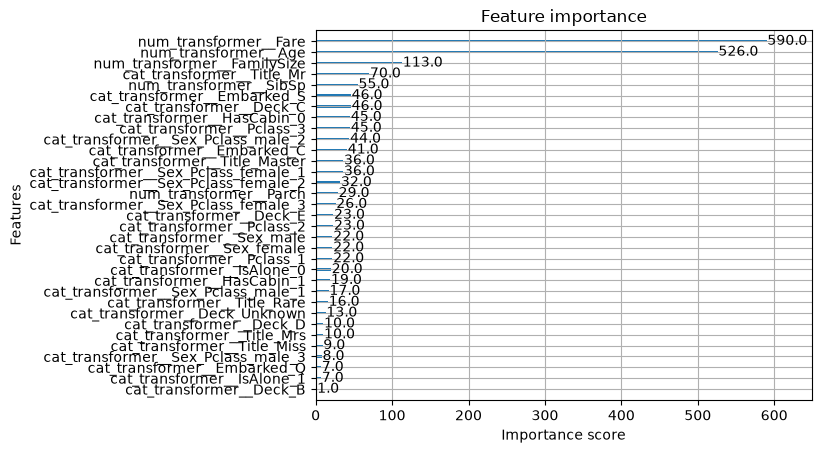

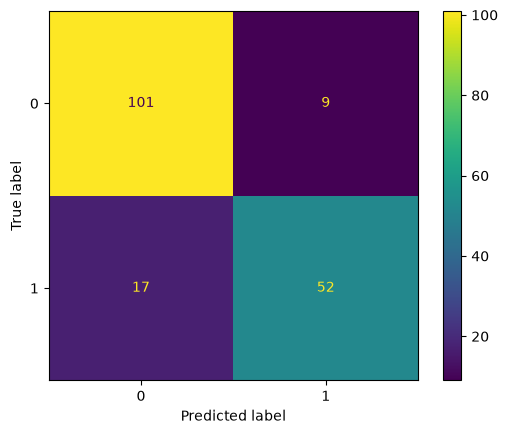

In [74]:
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from xgboost import plot_importance, plot_tree
import matplotlib.pyplot as plt
import graphviz
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

# num_features = ['Age',  'Fare' , 'FamilySize' ,'SibSp', 'Parch'] #
# cat_features = ['Sex', 'Sex_Pclass', 'Title', 'IsAlone', 'Pclass','HasCabin', 'Deck','Embarked' ] #  
num_features = ['Age',  'Fare', 'FamilySize','SibSp', 'Parch'] # 
cat_features = ['Pclass', 'Sex_Pclass' ,'Sex', 'Title', 'IsAlone', 'HasCabin', 'Deck', 'Embarked'] # 
FEATURES = num_features + cat_features
train_fe[FEATURES]
SEED = 151
X = train_fe[FEATURES]
y = train_fe['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=SEED
)
num_transformer = Pipeline(
    steps=[
        ('num_imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
cat_transformer = Pipeline(
    steps=[
        ('cat_imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ('num_transformer', num_transformer, num_features),
        ('cat_transformer', cat_transformer, cat_features)
    ]
)
# model = XGBClassifier(
#         max_depth= 5, 
#         min_child_weight= 3, 
#         colsample_bylevel= 0.8, 
#         colsample_bytree= 0.7, 
#         reg_lambda= 2, 
#         subsample= 0.9,
#         gamma=0.2,
#         learning_rate= 0.04
# )
model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=np.float64(0.2087055015743895),
              grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.04221078104707303), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3,  monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)

model_pipeline.fit(X_train, y_train)
preds = model_pipeline.predict(X_test)
probs = model_pipeline.predict_proba(X_test)[:,1]
train_preds = model_pipeline.predict(X_train)
train_probs = model_pipeline.predict_proba(X_train)[:,1]
#### 사용한 feature 확인
print("Used SEED/features:",SEED,"/",FEATURES)
#### 과적합 확인
print("Checking for overfitting...")
print(f"Train ROC AUC score: { roc_auc_score(y_train, train_probs):.4f}") 
print(f"Test ROC AUC score: { roc_auc_score(y_test, probs):.4f}")
print(f"Train Accuracy: { accuracy_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: { accuracy_score(y_test, preds):.4f}")
#### Cross-validation 점수확인
cross_val = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation ROC AUC scores:" )
print('CV ROC AUC mean score: {:.4f} (+/- {:.4f})'.format(cross_val.mean(), cross_val.std()))
# print('avg fit time: (+/- {})'.format(cross_val['fit_time'].mean(), cross_val['fit_time'].std()))
# print('avg score time: (+/- {})'.format(cross_val['score_time'].mean(), cross_val['score_time'].std()))
# print('avg test time: (+/- {})'.format(cross_val['test_time'].mean(), cross_val['test_time'].std()))
#### 모델의 피쳐 중요도 시각화
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
classifier = model_pipeline.named_steps['classifier']
classifier.get_booster().feature_names = list(feature_names)
plot_importance(model_pipeline.named_steps['classifier'])
#### 혼돈 행렬 시각화
print("Confusion Matrix:")
cm = confusion_matrix(y_test, preds)    
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(classification_report(y_test, preds, digits=4))

In [75]:
#################################################
# XGBClassifier  하이터파라미터 튜닝 후 적용
#################################################
model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=np.float64(0.2087055015743895),
              grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.04221078104707303), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3,  monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None)
model_pipeline = Pipeline(
    steps=[
        ('processor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X, y) #학습 
X_test = test_fe[FEATURES]
pred = model_pipeline.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Survived": pred.astype(int),
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [76]:
## 제출 2026-09-01 -5회차 전송
!kaggle competitions submit -c titanic -f submission.csv -m "baseline: XGBClassifier with Grid search"

9 submissions remaining today.
Successfully submitted to Titanic - Machine Learning from Disaster



  0%|          | 0.00/3.18k [00:00<?, ?B/s]
100%|██████████| 3.18k/3.18k [00:00<00:00, 4.80kB/s]
100%|██████████| 3.18k/3.18k [00:01<00:00, 2.24kB/s]


In [77]:
# 제출 이력과 점수 확인  
!kaggle competitions submissions -c titanic

     ref  fileName        date                        description                                            status                     publicScore  privateScore  
--------  --------------  --------------------------  -----------------------------------------------------  -------------------------  -----------  ------------  
55942732  submission.csv  2026-09-01 15:09:38.597000  baseline: XGBClassifier with Grid search               SubmissionStatus.COMPLETE  0.75837                    
55920164  submission.csv  2026-08-31 16:39:49.617000  baseline: RandomForest with Grid search                SubmissionStatus.COMPLETE  0.74880                    
55920100  submission.csv  2026-08-31 16:35:57.350000  baseline: LogisticRegression with Grid search          SubmissionStatus.COMPLETE  0.75598                    
55916941  submission.csv  2026-08-31 13:51:04.237000  baseline: LogisticRegression with feature engineering  SubmissionStatus.COMPLETE  0.77033                    
55916084  submis